## 1. import data + standardization 

In [77]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load your data
df = pd.read_csv('../data/Country-data.csv')
X = df.drop('country', axis=1)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. Apply PCA

This helps with:
- visualization
- noise reduction

In [78]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [79]:
# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['country'] = df['country']

# View the 'Loadings' to see if PC1 is indeed the "Health/Development" axis
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)
print(loadings)

                 PC1       PC2
child_mort -0.419519  0.192884
exports     0.283897  0.613163
health      0.150838 -0.243087
imports     0.161482  0.671821
income      0.398441  0.022536
inflation  -0.193173 -0.008404
life_expec  0.425839 -0.222707
total_fer  -0.403729  0.155233
gdpp        0.392645 -0.046022


## 3. K-MEANS and Poorest Group

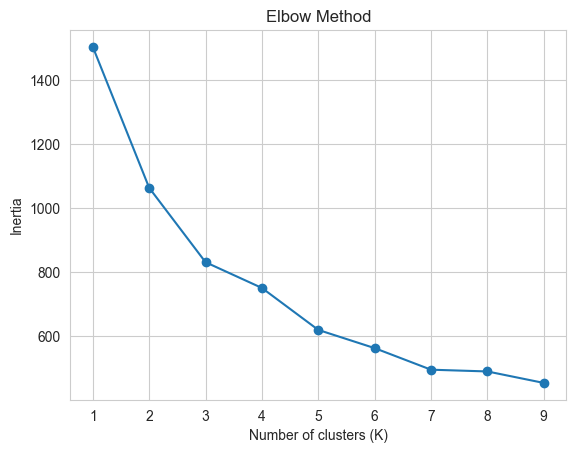

In [80]:
from sklearn.cluster import KMeans

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [81]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(pca_components)

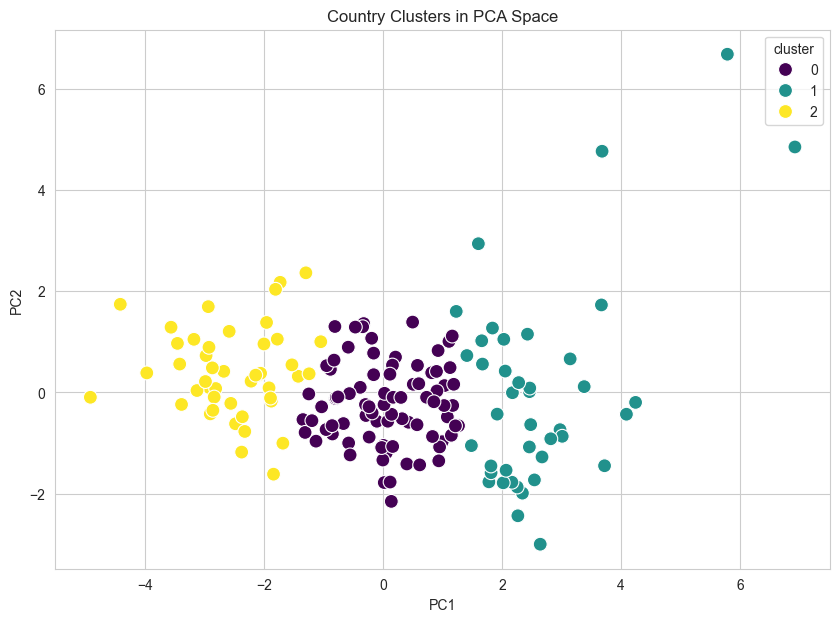

In [82]:
# 1. Ensure the clusters are in the same dataframe you are plotting
pca_df['cluster'] = df['cluster']

# 2. Plotting with Seaborn
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster',
    data=pca_df, 
    palette='viridis', 
    s=100
)

plt.title('Country Clusters in PCA Space')
plt.show()

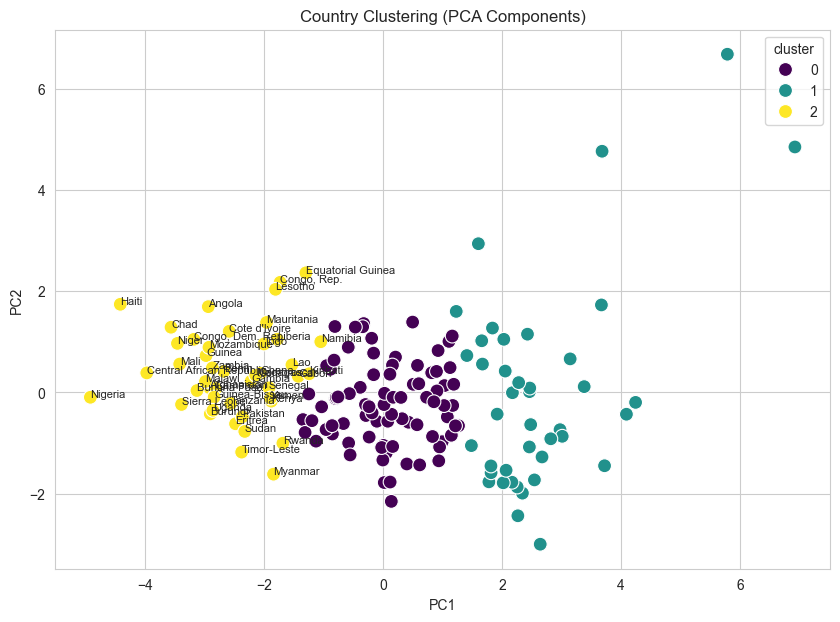

In [97]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100)

# Optional: Label the poorest countries on the plot
for i in range(pca_df.shape[0]):
    if df.loc[i, 'cluster'] == poorest_cluster_id:
        plt.text(pca_df.PC1[i], pca_df.PC2[i], pca_df.country[i], fontsize=8)

plt.title('Country Clustering (PCA Components)')
plt.show()

In [84]:
# Identify the cluster with the highest child mortality and lowest GDP

cluster_summary = df.groupby('cluster')[['child_mort', 'gdpp', 'income']].mean()
poorest_cluster_id = cluster_summary['gdpp'].idxmin()

print(f"The Poorest Group is Cluster {poorest_cluster_id}")
print(df[df['cluster'] == poorest_cluster_id]['country'].values)

The Poorest Group is Cluster 2
['Afghanistan' 'Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'Kenya' 'Kiribati'
 'Lao' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania'
 'Mozambique' 'Myanmar' 'Namibia' 'Niger' 'Nigeria' 'Pakistan' 'Rwanda'
 'Senegal' 'Sierra Leone' 'Sudan' 'Tanzania' 'Timor-Leste' 'Togo' 'Uganda'
 'Yemen' 'Zambia']


In [85]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pca_components, df['cluster'] )
print("Silhouette Score:", round(score, 3))


Silhouette Score: 0.379


In [86]:
from sklearn.metrics import calinski_harabasz_score
score = calinski_harabasz_score(pca_components, df['cluster'])
print("Calinski-Harabasz Index:", round(score, 3))


Calinski-Harabasz Index: 127.709


In [87]:
# Compare the means of the clusters
# We look for High child_mort and Low gdpp/income
cluster_profile = df.groupby('cluster')[['child_mort', 'gdpp', 'income', 'life_expec']].mean()
print(cluster_profile)

         child_mort          gdpp        income  life_expec
cluster                                                    
0         23.230864   6202.888889  11856.172840   72.303704
1          5.339024  38765.121951  42726.829268   79.419512
2         95.344444   1626.888889   3355.844444   59.333333


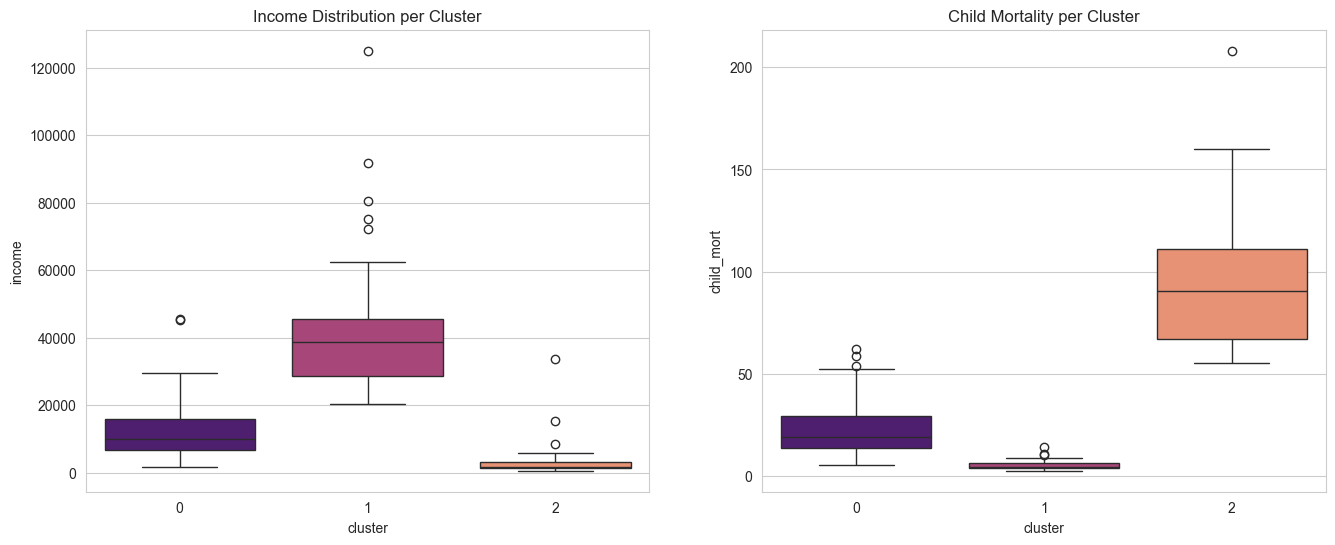

In [88]:
# Create a 1x2 subplot to compare Income vs. Child Mortality
plt.figure(figsize=(16, 6))

# Plot 1: Income
plt.subplot(1, 2, 1)
sns.boxplot(x='cluster', y='income', data=df, palette='magma')
plt.title('Income Distribution per Cluster')

# Plot 2: Child Mortality (The "Health" perspective)
plt.subplot(1, 2, 2)
sns.boxplot(x='cluster', y='child_mort', data=df, palette='magma')
plt.title('Child Mortality per Cluster')

plt.show()

## 4 .DBSCAN

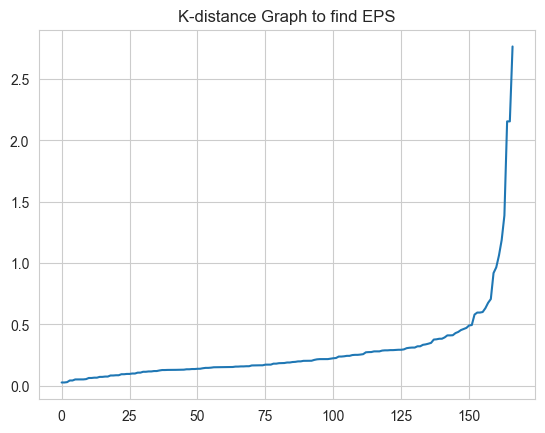

In [93]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Find the distance to the nearest neighbor for each point
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(pca_components)
distances, indices = nbrs.kneighbors(pca_components)

# Sort and plot
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
plt.title('K-distance Graph to find EPS')
plt.show()

In [105]:
from sklearn.cluster import DBSCAN

# 1. Initialize DBSCAN
# eps: The distance to neighbors. 
# min_samples: Min points to form a "dense" region.

dbscan = DBSCAN(eps=0.51, min_samples=2) 

In [106]:
# 2. Fit on the PCA data
df['dbscan_cluster'] = dbscan.fit_predict(pca_components)

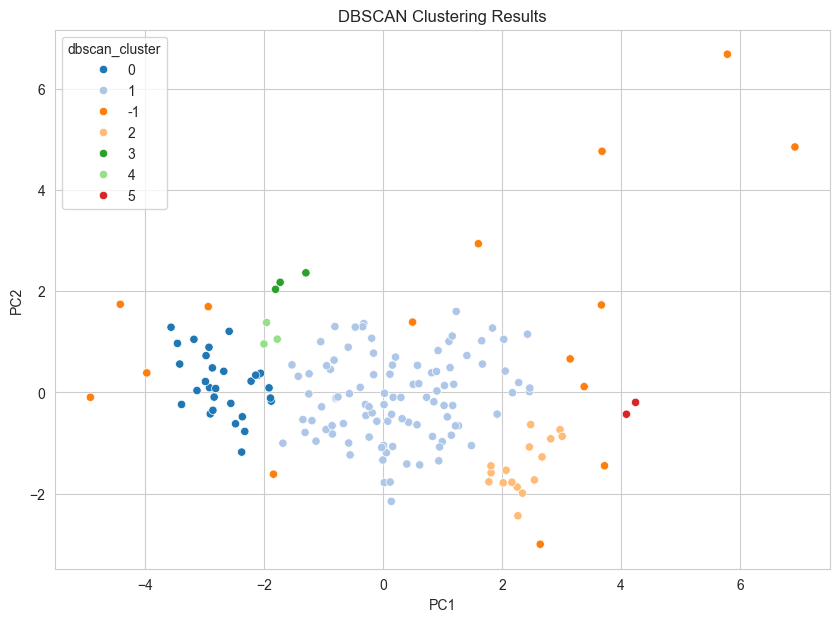

In [107]:
# Sync the labels
pca_df['dbscan_cluster'] = df['dbscan_cluster'].astype(str)

plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', hue='dbscan_cluster', data=pca_df, palette='tab20')
plt.title('DBSCAN Clustering Results')
plt.show()

In [108]:
# 3. Check the results
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 1    99
 0    29
 2    16
-1    15
 3     3
 4     3
 5     2
Name: count, dtype: int64


In [109]:
dbscan_analysis = df.groupby('dbscan_cluster')[['child_mort', 'gdpp', 'income']].mean()
print(dbscan_analysis)

                child_mort          gdpp        income
dbscan_cluster                                        
-1               49.613333  31491.066667  31876.533333
 0               94.606897    865.379310   1946.034483
 1               22.951515   8483.101010  15197.777778
 2                4.125000  41237.500000  37312.500000
 3               91.533333   7003.333333  13756.666667
 4               92.333333    671.666667   1743.333333
 5                6.750000  72450.000000  90250.000000


In [111]:
print("--- Cluster 4 (Extreme Poverty) ---")
print(df[df['dbscan_cluster'] == 0]['country'].values)


--- Cluster 4 (Extreme Poverty) ---
['Afghanistan' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon' 'Chad'
 'Comoros' 'Congo, Dem. Rep.' "Cote d'Ivoire" 'Eritrea' 'Gambia' 'Ghana'
 'Guinea' 'Guinea-Bissau' 'Kenya' 'Madagascar' 'Malawi' 'Mali'
 'Mozambique' 'Niger' 'Pakistan' 'Senegal' 'Sierra Leone' 'Sudan'
 'Tanzania' 'Timor-Leste' 'Uganda' 'Yemen' 'Zambia']


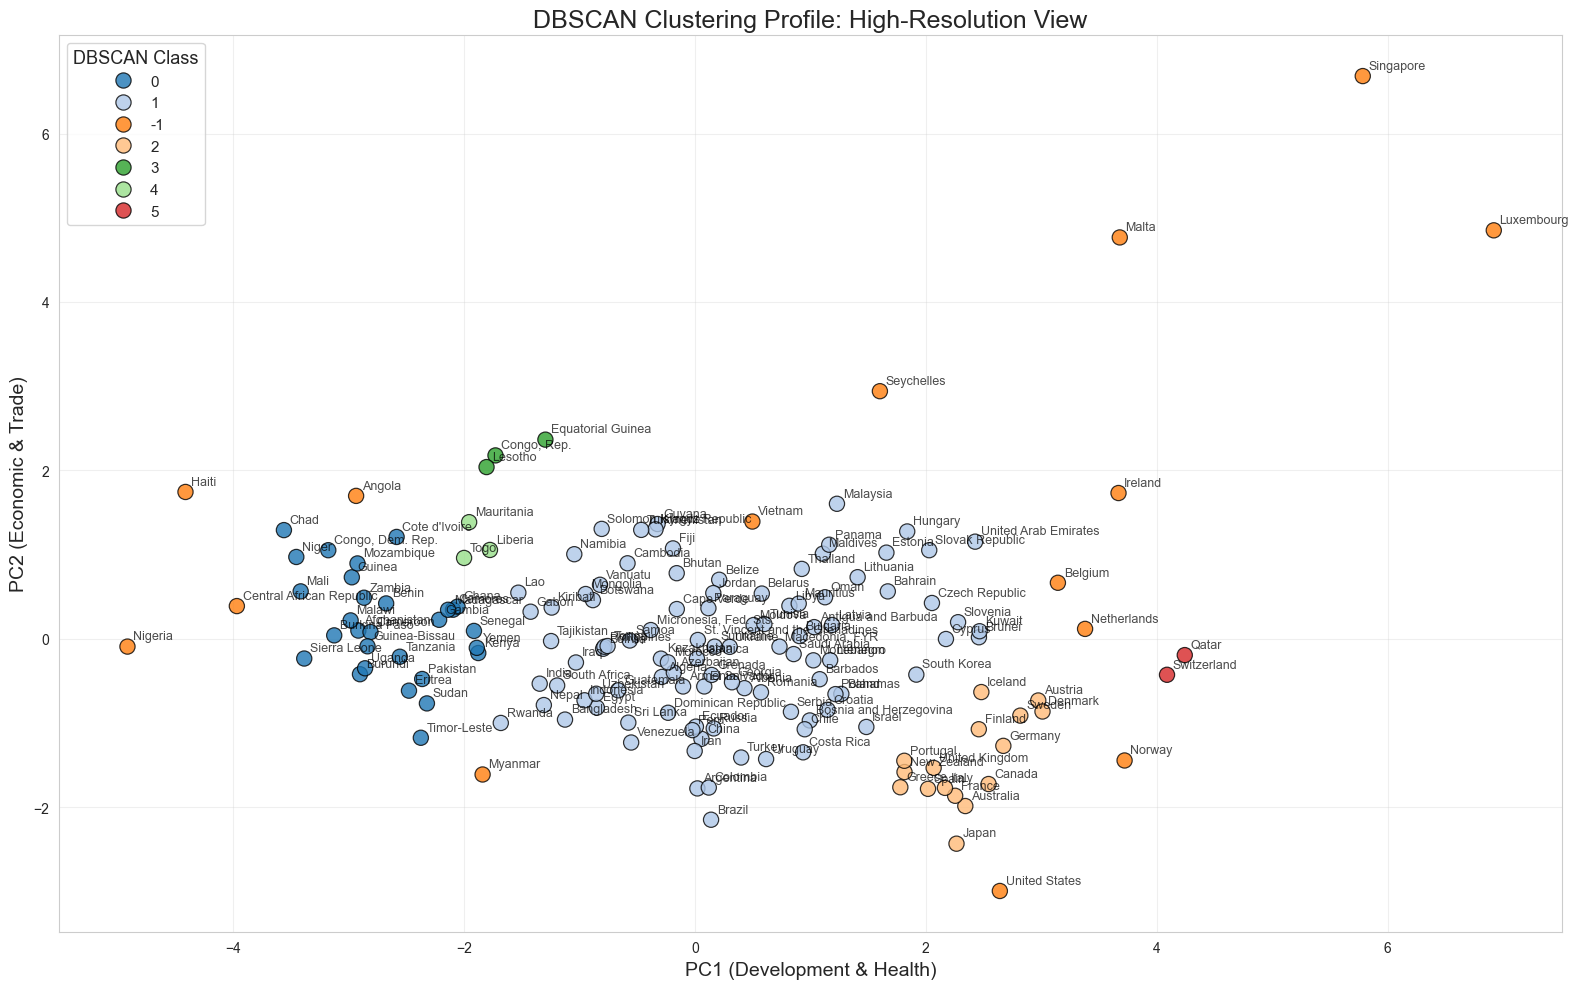

In [114]:
# 1. Sync the names and clusters to the plotting dataframe
pca_df['country'] = df['country']
pca_df['dbscan_cluster'] = df['dbscan_cluster'].astype(str) # Ensure it's treated as categories

# 2. Setup the plot area
plt.figure(figsize=(16, 10)) # Wider figure to give names more space
sns.set_style("whitegrid")

# 3. Create the base scatter plot
# Using the default palette ensures contrast between the 6 groups and Noise (-1)
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='dbscan_cluster', 
    data=pca_df, 
    palette='tab20', # 'Set2' provides distinct colors for small numbers of clusters
    s=120, 
    edgecolor='black', 
    alpha=0.8
)

# 4. Add the labels (The key part!)
# This loops through the data and adds the 'country' text at (PC1, PC2)
for i in range(pca_df.shape[0]):
    plt.text(
        x=pca_df.PC1[i] + 0.05, # Nudge text to the right slightly so it doesn't overlap the dot
        y=pca_df.PC2[i] + 0.05, # Nudge text up slightly
        s=pca_df.country[i], 
        fontdict=dict(color='black', alpha=0.7, size=9), # Clear, readable font
        verticalalignment='bottom',
        horizontalalignment='left'
    )

# 5. Final graph polishing
plt.title('DBSCAN Clustering Profile: High-Resolution View', fontsize=18)
plt.xlabel('PC1 (Development & Health)', fontsize=14)
plt.ylabel('PC2 (Economic & Trade)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='DBSCAN Class', title_fontsize='13', fontsize='11')

plt.tight_layout() # Adjust layout to ensure labels fit within the figure
plt.show()

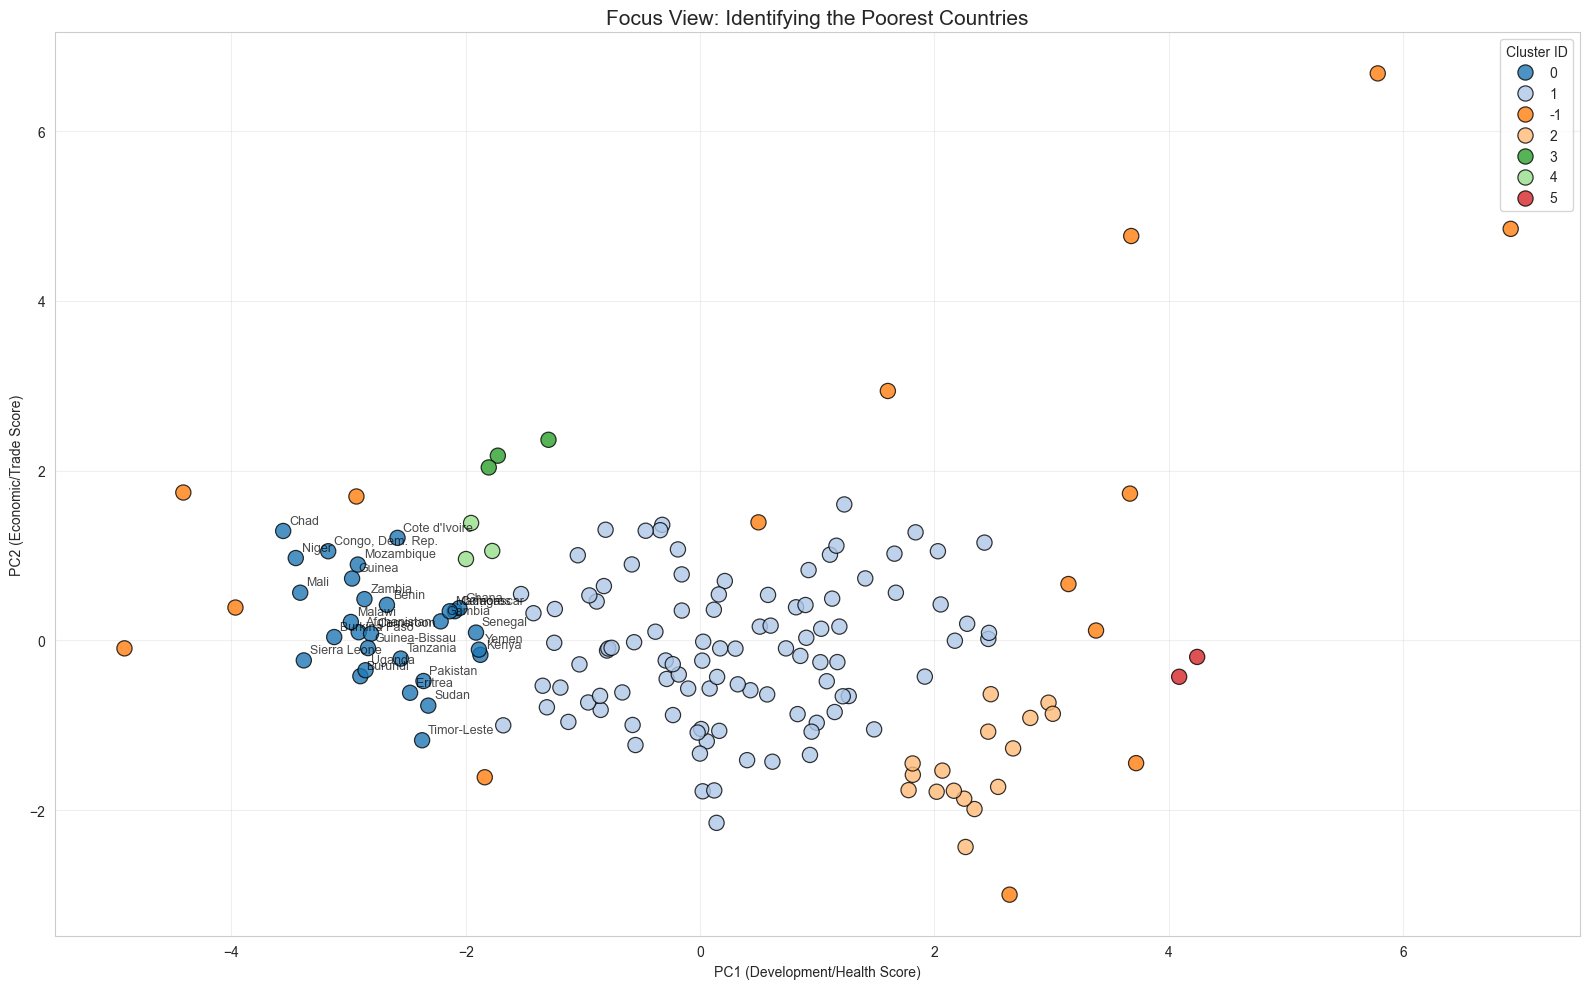

In [124]:
# 2. Define the clusters we consider "poor" based on your results
poor_clusters = ['0']

plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# 3. Create the scatter plot
# We use a palette that makes the poor clusters stand out
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='dbscan_cluster', 
    data=pca_df, 
    palette='tab20', 
    s=120, 
    edgecolor='black', 
    alpha=0.8
)

# 4. Add names ONLY for the poor countries
for i in range(pca_df.shape[0]):
    current_cluster = pca_df.dbscan_cluster[i]
    
    if current_cluster in poor_clusters:
        plt.text(
            x=pca_df.PC1[i] + 0.05, 
            y=pca_df.PC2[i] + 0.05, 
            s=pca_df.country[i], 
            fontdict=dict(color='black', alpha=0.7, size=9), # Clear, readable font
            verticalalignment='bottom',
            horizontalalignment='left'
        )

# 5. Final touches
plt.title('Focus View: Identifying the Poorest Countries', fontsize=15)
plt.xlabel('PC1 (Development/Health Score)')
plt.ylabel('PC2 (Economic/Trade Score)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster ID')
plt.tight_layout() # Adjust layout to ensure labels fit within the figure
plt.show()

In [127]:
dbscan_outliers = df[df['dbscan_cluster'] == -1]['country'].tolist()
print(dbscan_outliers)

['Angola', 'Belgium', 'Central African Republic', 'Haiti', 'Ireland', 'Luxembourg', 'Malta', 'Myanmar', 'Netherlands', 'Nigeria', 'Norway', 'Seychelles', 'Singapore', 'United States', 'Vietnam']


In [128]:
k_means_array = np.array(['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon',
 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.',
 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon',
 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Kenya', 'Kiribati',
 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania',
 'Mozambique', 'Myanmar', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda',
 'Senegal', 'Sierra Leone', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda',
 'Yemen', 'Zambia'])

dbscan_outliers = ['Angola', 'Belgium', 'Central African Republic', 'Haiti', 'Ireland',
                   'Luxembourg', 'Malta', 'Myanmar', 'Netherlands', 'Nigeria', 'Norway',
                   'Qatar', 'Seychelles', 'Singapore', 'Switzerland', 'United States', 'Vietnam']



#  Perform intersection
intersection = list(set(k_means_array) & set(dbscan_outliers))

print(sorted(intersection))

['Angola', 'Central African Republic', 'Haiti', 'Myanmar', 'Nigeria']


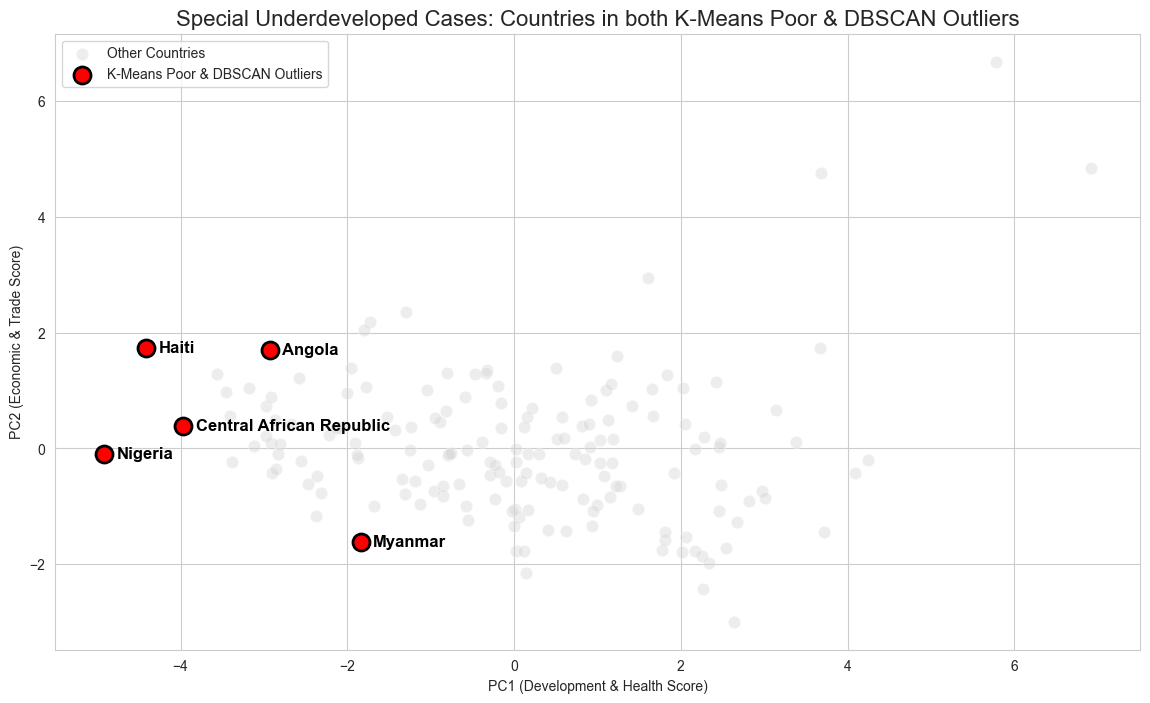

In [129]:

# 1. Define the specific list from your intersection
intersection_countries = ['Angola', 'Central African Republic', 'Haiti', 'Myanmar', 'Nigeria']

# 2. Setup the plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 3. Plot all countries in a neutral light grey to provide background context
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=pca_df, 
    color='lightgrey', 
    s=80, 
    alpha=0.4, 
    label='Other Countries'
)

# 4. Highlight the 5 intersection countries in a bold color
# We filter the PCA dataframe for just these names
highlight_df = pca_df[pca_df['country'].isin(intersection_countries)]

sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=highlight_df, 
    color='red', 
    s=150, 
    edgecolor='black', 
    linewidth=2,
    label='K-Means Poor & DBSCAN Outliers'
)

# 5. Add the country names for the highlighted dots
for i, row in highlight_df.iterrows():
    plt.text(
        x=row['PC1'] + 0.15, 
        y=row['PC2'], 
        s=row['country'], 
        fontsize=12, 
        fontweight='bold', 
        color='black',
        verticalalignment='center'
    )

# 6. Graph Polishing
plt.title('Special Underdeveloped Cases: Countries in both K-Means Poor & DBSCAN Outliers', fontsize=16)
plt.xlabel('PC1 (Development & Health Score)')
plt.ylabel('PC2 (Economic & Trade Score)')
plt.legend()
plt.show()

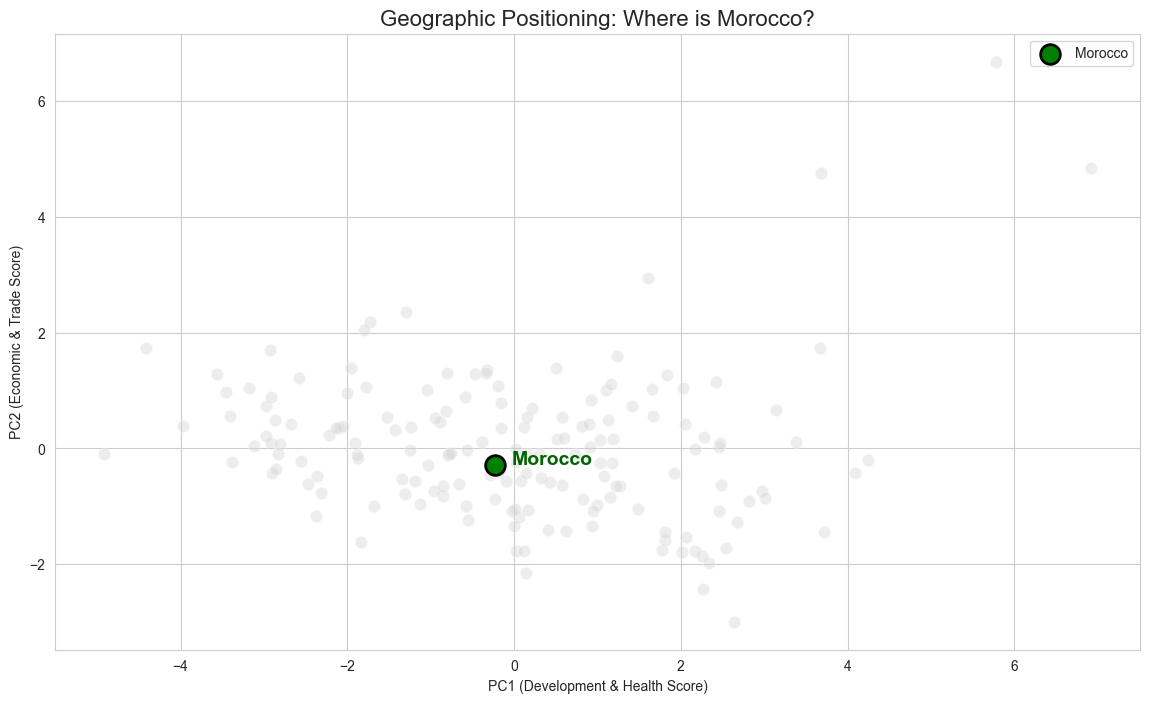

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 2. Plot all countries in a neutral light grey background
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=pca_df, 
    color='lightgrey', 
    s=80, 
    alpha=0.4
)

# 3. Highlight Morocco specifically
morocco_data = pca_df[pca_df['country'] == 'Morocco']

if not morocco_data.empty:
    sns.scatterplot(
        x='PC1', 
        y='PC2', 
        data=morocco_data, 
        color='green', # Using green for the Moroccan flag
        s=200, 
        edgecolor='black', 
        linewidth=2,
        label='Morocco'
    )

    # 4. Add the label
    plt.text(
        x=morocco_data.PC1.values[0] + 0.2, 
        y=morocco_data.PC2.values[0], 
        s='Morocco', 
        fontsize=14, 
        fontweight='bold', 
        color='darkgreen'
    )
else:
    print("Morocco not found in the dataset. Please check the spelling.")

# 5. Graph Polishing
plt.title('Geographic Positioning: Where is Morocco?', fontsize=16)
plt.xlabel('PC1 (Development & Health Score)')
plt.ylabel('PC2 (Economic & Trade Score)')
plt.legend()
plt.show()